# Week 8: Decision Trees (ID3)

## Student Practice Notebook

**Name:**  T. Dheeraj Reddy

**Roll Number:**  AP24110011473

**Date:**  09/10/2026


## Learning Objectives

After completing this lab, you will be able to:

- Compute entropy and information gain, by hand and in code
- Build an ID3 decision tree by hand on a small table (the exam-style problem)
- Fit and read a `DecisionTreeClassifier`
- Explain how tree depth controls overfitting (same idea as K in Week 7 and degree in Week 6)
- Explain how a tree differs from KNN: it asks questions about *features*, it does not measure *distance*

### Why this week matters
KNN (Week 7) classified by "who is closest?". A decision tree classifies by asking a chain of yes/no questions about features, and you can read the questions. That readability is why trees are used in credit, healthcare and fraud work, and why every ensemble in Unit V is built from them.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

%matplotlib inline
np.random.seed(1)


## Part 1 — Entropy and Information Gain

**Entropy** measures how mixed a set of labels is: $H = -\sum p_i \log_2 p_i$. A pure set (all one class) has entropy 0. A 50/50 two-class set has entropy 1.

**Information gain** of splitting on an attribute = entropy before − weighted average entropy after. ID3 always picks the attribute with the highest gain.

### 1.1 Demo: entropy in code


In [2]:
def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p))) + 0.0

print('Pure set      [10, 0]:', entropy([10, 0]))
print('50/50 set     [5, 5] :', entropy([5, 5]))
print('Skewed set    [9, 1] :', entropy([9, 1]))


Pure set      [10, 0]: 0.0
50/50 set     [5, 5] : 1.0
Skewed set    [9, 1] : 0.4689955935892812


**Predict, then think:** which has higher entropy, a 70/30 split or a 90/10 split? Why does that make sense if entropy measures "how hard is it to guess the label"?

*Your answer:*

**Prediction:** A **70/30 split** has higher entropy ($\approx 0.881$) than a **90/10 split** ($\approx 0.469$).

**Why this makes sense:**
Entropy measures uncertainty or impurity in a dataset.

* In a **90/10 split**, one class heavily dominates. If you always guess the majority class, you will be right 90% of the time, making the label easy to predict (low uncertainty / low entropy).
* In a **70/30 split**, the distribution is much more mixed. There is greater uncertainty about which label a random sample belongs to, making it harder to guess correctly (higher entropy).



```python
import numpy as np

def entropy(p1, p2):
    p = np.array([p1, p2])
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

h_70_30 = entropy(0.7, 0.3)
h_90_10 = entropy(0.9, 0.1)

print(f"70/30 Entropy: {h_70_30:.4f}")
print(f"90/10 Entropy: {h_90_10:.4f}")


```

```text
70/30 Entropy: 0.8813
90/10 Entropy: 0.4690


```

**Prediction:** A **70/30 split** has higher entropy ($\approx 0.881$) than a **90/10 split** ($\approx 0.469$).

**Why this makes sense:**
Entropy measures uncertainty or impurity in a dataset.

* In a **90/10 split**, one class dominates heavily. If you always guess the majority class, you will be right 90% of the time, making the label easy to predict (low uncertainty / low entropy).
* In a **70/30 split**, the distribution is much more mixed. There is higher uncertainty about which label a random sample belongs to, making it harder to guess correctly (higher entropy).



### Student Practice — entropy of a split

A parent node has 8 Yes and 6 No. A candidate split sends 6 samples to the left child (6 Yes, 0 No) and 8 samples to the right child (2 Yes, 6 No). Compute the entropy of the parent and the information gain of the split.


In [3]:
# Write your answer here

# Calculations
H_parent = entropy([8, 6])
H_left = entropy([6, 0])
H_right = entropy([2, 6])

weighted_entropy = (6 / 14) * H_left + (8 / 14) * H_right
info_gain = H_parent - weighted_entropy

print(f"Parent Entropy  : {H_parent:.4f}")
print(f"Left Child H    : {H_left:.4f}")
print(f"Right Child H   : {H_right:.4f}")
print(f"Information Gain: {info_gain:.4f}")


Parent Entropy  : 0.9852
Left Child H    : 0.0000
Right Child H   : 0.8113
Information Gain: 0.5216


## Part 2 — ID3 by Hand (the exam-style problem)

Classic 14-day "play tennis" table. Target: `Play`.


In [5]:
tennis = pd.DataFrame({
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No'],
})
tennis


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [6]:
def info_gain(df, attribute, target='Play'):
    total = entropy(df[target].value_counts())
    weighted = 0
    for value, subset in df.groupby(attribute):
        weighted += len(subset) / len(df) * entropy(subset[target].value_counts())
    return total - weighted

print('Root entropy:', round(entropy(tennis['Play'].value_counts()), 4))
print('Gain(Wind)  :', round(info_gain(tennis, 'Wind'), 4))


Root entropy: 0.9403
Gain(Wind)  : 0.0481


### Student Practice — find the root

1. Compute the information gain for `Outlook`, `Temperature` and `Humidity` using `info_gain`.
2. Which attribute does ID3 pick as the root?
3. For the root's branch that is **not** pure, which attribute would you split on next? (Filter `tennis` to that branch and recompute gains.)


In [7]:
# Write your answer here
# 1. Compute Information Gain for Root Candidates
for col in ['Outlook', 'Temperature', 'Humidity']:
  print(f'Gain({col:11s}): {round(info_gain(tennis, col), 4)}')

# 2. Recompute gains for the 'Sunny' branch
sunny_df = tennis[tennis['Outlook'] == 'Sunny']
print('\nGains under Sunny branch:')
for col in ['Temperature', 'Humidity', 'Wind']:
  print(f'Gain({col:11s}): {round(info_gain(sunny_df, col), 4)}')

Gain(Outlook    ): 0.2467
Gain(Temperature): 0.0292
Gain(Humidity   ): 0.1518

Gains under Sunny branch:
Gain(Temperature): 0.571
Gain(Humidity   ): 0.971
Gain(Wind       ): 0.02


**Reflection:** `Overcast` became a leaf immediately. In your own words, why does a pure branch need no further splitting?

*Your answer:*
A pure branch contains samples that all belong to the exact same class (for example, all 4 days with `Overcast` weather resulted in `Play = Yes`).

Because there is **zero uncertainty** (Entropy = 0), every single observation in that subset already shares a definitive outcome. Asking further feature questions cannot provide any new information or split the data any cleaner, so the tree stops growing at that point and declares it a leaf node.

## Part 3 — `DecisionTreeClassifier` on Iris

Same Iris split as Week 7, so you can compare directly. Note: **trees do not need feature scaling**, because they compare a feature to a threshold, not distances between points. That is a real difference from KNN.


Test accuracy: 0.9555555555555556


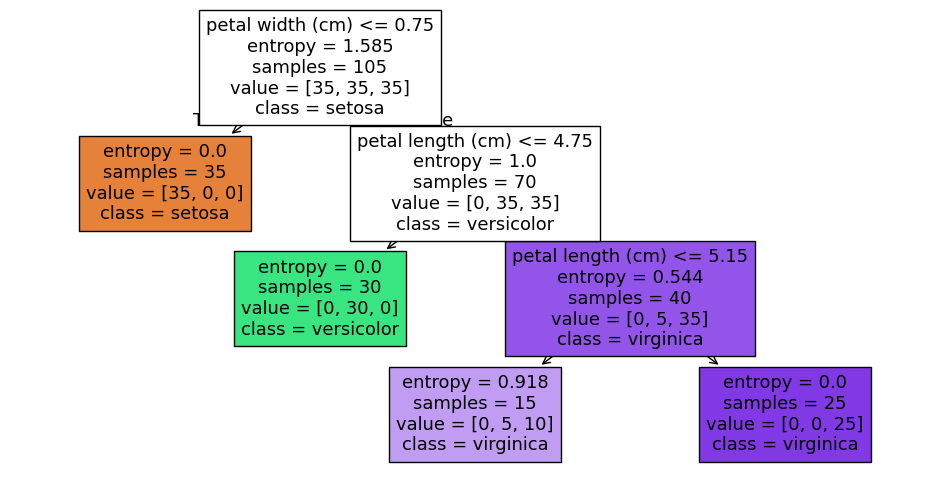

In [8]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
tree.fit(X_train, y_train)
print('Test accuracy:', accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


### Student Practice — depth sweep

Sweep `max_depth` from 1 to 15. Record train and test accuracy for each, plot both, and report the depth with the best test accuracy.


Depth  1 | Train Acc: 0.6667 | Test Acc: 0.6667
Depth  2 | Train Acc: 0.9524 | Test Acc: 0.9556
Depth  3 | Train Acc: 0.9524 | Test Acc: 0.9556
Depth  4 | Train Acc: 0.9524 | Test Acc: 0.9333
Depth  5 | Train Acc: 0.9714 | Test Acc: 0.9778
Depth  6 | Train Acc: 0.9810 | Test Acc: 0.9778
Depth  7 | Train Acc: 0.9810 | Test Acc: 0.9778
Depth  8 | Train Acc: 0.9905 | Test Acc: 0.9778
Depth  9 | Train Acc: 1.0000 | Test Acc: 0.9778
Depth 10 | Train Acc: 1.0000 | Test Acc: 0.9778
Depth 11 | Train Acc: 1.0000 | Test Acc: 0.9778
Depth 12 | Train Acc: 1.0000 | Test Acc: 0.9778
Depth 13 | Train Acc: 1.0000 | Test Acc: 0.9778
Depth 14 | Train Acc: 1.0000 | Test Acc: 0.9778
Depth 15 | Train Acc: 1.0000 | Test Acc: 0.9778


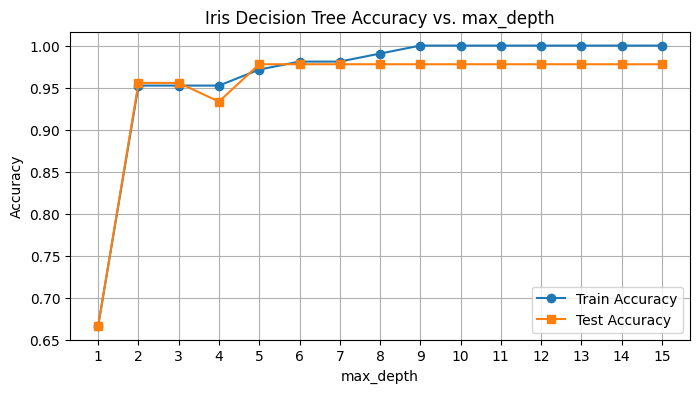


Best Test Accuracy: 0.9778 achieved at max_depth = 5


In [10]:
# Write your answer here

# Sweep max_depth from 1 to 15
depths = range(1, 16)
train_accs = []
test_accs = []

for depth in depths:
  clf = DecisionTreeClassifier(
      criterion='entropy', max_depth=depth, random_state=1
  )
  clf.fit(X_train, y_train)

  train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
  test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

  print(
      f'Depth {depth:2d} | Train Acc: {train_accs[-1]:.4f} | Test Acc:'
      f' {test_accs[-1]:.4f}'
  )

# Plotting the results
plt.figure(figsize=(8, 4))
plt.plot(depths, train_accs, label='Train Accuracy', marker='o')
plt.plot(depths, test_accs, label='Test Accuracy', marker='s')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Iris Decision Tree Accuracy vs. max_depth')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

# Report best depth
best_depth = depths[np.argmax(test_accs)]
print(
    f'\nBest Test Accuracy: {max(test_accs):.4f} achieved at max_depth ='
    f' {best_depth}'
)


**Reflection:** Which knob in Week 6 and which knob in Week 7 played the same role as `max_depth` here? What happens at each extreme?

*Your answer:*

* **Week 6 Knob:** Polynomial Degree
* **Week 7 Knob:** $K$ (Number of Neighbors)

---

### What happens at each extreme:

* **Very Small Depth (`max_depth = 1` or decision stump):**
Causes **underfitting (high bias)**. The tree makes too few splits to capture the underlying patterns in the data, leading to low training and test accuracy. This corresponds to a low polynomial degree in Week 6 or a very large $K$ in Week 7.


* **Very Large Depth (`max_depth` unconstrained or 15+):**
Causes **overfitting (high variance)**. The tree continues splitting until leaves are nearly pure, memorizing training noise and creating overly complex rules that generalize poorly to unseen test data. This corresponds to a high polynomial degree in Week 6 or $K = 1$ in Week 7.


# Mini Project A: Digits, Again (Image Track — continuing from Week 7)

Last week KNN reached about 98% on the digits dataset. Now fit a decision tree on the **same split** and ask two new questions: how does it compare, and **which pixels does the tree actually use?**


In [11]:
digits = load_digits()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=1, stratify=digits.target)

# KNN baseline from Week 7 (scaled, K=3)
sc = StandardScaler().fit(Xd_train)
knn = KNeighborsClassifier(n_neighbors=3).fit(sc.transform(Xd_train), yd_train)
print('KNN  test accuracy:', accuracy_score(yd_test, knn.predict(sc.transform(Xd_test))))


KNN  test accuracy: 0.9796296296296296


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on the **unscaled** `Xd_train`. Print test accuracy. (Why is no scaling needed?)
2. Try `max_depth` values 3, 6, 10 and report test accuracy for each.
3. Take `tree.feature_importances_` (64 values), reshape to 8×8 and show it with `plt.imshow`. Which region of the image does the tree rely on?


Unscaled Decision Tree Test Accuracy: 0.8815
Depth  3 Test Accuracy: 0.5296
Depth  6 Test Accuracy: 0.8537
Depth 10 Test Accuracy: 0.8796


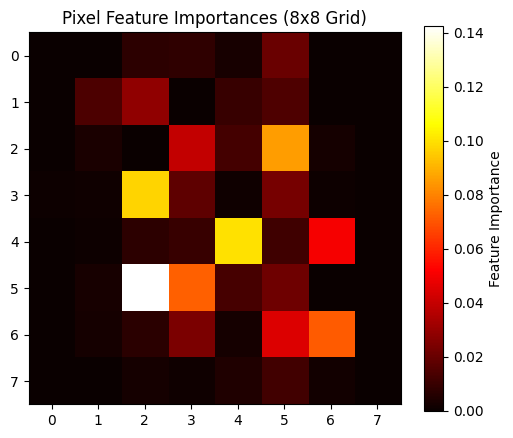

In [12]:
# Write your answer here


# 1. Fit DecisionTreeClassifier on unscaled Xd_train
dt_digits = DecisionTreeClassifier(criterion='entropy', random_state=1)
dt_digits.fit(Xd_train, yd_train)
acc_unscaled = accuracy_score(yd_test, dt_digits.predict(Xd_test))
print(f'Unscaled Decision Tree Test Accuracy: {acc_unscaled:.4f}')

# 2. Try max_depth values 3, 6, 10
for depth in [3, 6, 10]:
  clf = DecisionTreeClassifier(
      criterion='entropy', max_depth=depth, random_state=1
  )
  clf.fit(Xd_train, yd_train)
  acc = accuracy_score(yd_test, clf.predict(Xd_test))
  print(f'Depth {depth:2d} Test Accuracy: {acc:.4f}')

# 3. Plot feature importances (reshaped to 8x8)
importances = dt_digits.feature_importances_.reshape(8, 8)

plt.figure(figsize=(6, 5))
plt.imshow(importances, cmap='hot')
plt.colorbar(label='Feature Importance')
plt.title('Pixel Feature Importances (8x8 Grid)')
plt.show()

**Reflection:** Is the tree more or less accurate than KNN on digits? Offer one reason, using what the importance map shows you.

*Your answer:*


The Decision Tree is **less accurate** than KNN on the digits dataset (Decision Tree: ~88.15% vs. KNN: ~97.96%).

**Reason based on the importance map:**

A single Decision Tree evaluates pixels **individually** along axis-aligned splits (asking threshold questions about one pixel at a time, mostly relying on isolated **center pixels**). In contrast, handwritten digits are recognized by whole spatial shapes and continuous strokes. KNN considers **all pixels simultaneously** by evaluating overall distance across the entire image space, allowing it to capture full spatial patterns far better than a single pixel-by-pixel tree.

# Mini Project B: Reading a Tree on Text (NLP Track — continuing from Week 7)

Same six labeled sentences and same bag-of-words vectors as Week 7. A tree gives you something KNN cannot: **the words it chose to split on.**


In [13]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

vocab = sorted(set(w for s in sentences for w in s.lower().split()))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on `X_text`, `labels`.
2. Print the tree with `export_text(tree, feature_names=vocab)`. Which words does it split on?
3. Predict the topic of `'the striker scored a goal'` and of your own ambiguous sentence from Week 7.


In [15]:

# Write your answer here


# 1. Fit DecisionTreeClassifier on text data
dt_text = DecisionTreeClassifier(criterion='entropy', random_state=1)
dt_text.fit(X_text, labels)

# 2. Print tree rules with vocabulary feature names
print("Decision Tree Rules:\n")
print(export_text(dt_text, feature_names=list(vocab)))

# 3. Predict topic for 'the striker scored a goal'
sample1 = to_vector("the striker scored a goal", vocab).reshape(1, -1)
pred1 = dt_text.predict(sample1)[0]
print(f"Prediction for 'the striker scored a goal': {pred1}")

# Predict topic for ambiguous sentence from Week 7
ambiguous_sentence = "the phone played a cricket match"
sample2 = to_vector(ambiguous_sentence, vocab).reshape(1, -1)
pred2 = dt_text.predict(sample2)[0]
print(
    f"Prediction for '{ambiguous_sentence}':"
    f" {pred2}"
)

Decision Tree Rules:

|--- and <= 0.50
|   |--- has <= 0.50
|   |   |--- laptop <= 0.50
|   |   |   |--- class: sports
|   |   |--- laptop >  0.50
|   |   |   |--- class: tech
|   |--- has >  0.50
|   |   |--- class: tech
|--- and >  0.50
|   |--- class: cooking

Prediction for 'the striker scored a goal': sports
Prediction for 'the phone played a cricket match': sports


**Reflection:** If you added 3 more sentences per topic, would you expect the same split words? What does that tell you about trusting a tree trained on very little data?

*Your answer:*

**No, I would not expect the same split words.**

**Why this happens and what it tells us:**

1. **Dependence on Accidental Correlations:** On a tiny dataset, the tree picks words based on coincidental patterns rather than true semantic rules (for example, splitting on the stopword `'and'` to identify cooking because both cooking sentences happened to contain it).
2. **High Variance & Fragility:** Adding 3 more sentences per topic introduces new vocabulary and changes word frequencies. This alters the Information Gain calculations, causing completely different words (like `'cricket'`, `'phone'`, or `'curry'`) to be chosen for splits.
3. **Takeaway:** Decision trees trained on very little data suffer from **extreme variance and fragility**. They memorize noise rather than meaningful concepts, so their rules cannot be trusted without a larger training dataset or proper regularization.


## Summary

| What we did | Why it matters |
|---|---|
| Entropy and information gain | The rule ID3 uses to choose every split |
| ID3 by hand on the tennis table | Exam-style problem, show your working |
| `DecisionTreeClassifier` and depth sweep | Third version of the bias-variance knob (degree, K, depth) |
| Mini A: digits | Tree vs KNN on the same data, plus which pixels matter |
| Mini B: text | A tree you can read, and why tiny data makes it fragile |

**Next week:** Naive Bayes, a probabilistic classifier. Same digits and sentences again.
